In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from cmdstanpy import CmdStanModel

In [3]:
N = 100
alpha = 2.3
sigma = 2.0
slope = 4.0
x = np.random.normal(size=N)
y = alpha + slope * x + sigma * np.random.normal(0, sigma, size=N)

data_dict = {
    "N": len(y),
    "y": y,
    "x": x
}

In [4]:
model = CmdStanModel(stan_file="./stanmodel.stan")


In [5]:
fit = model.sample(
    data=data_dict, 
    chains=4, 
    iter_warmup=25, 
    iter_sampling=100,)

print(fit.diagnose())



09:54:24 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|                                                                        | 0/125 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|                                                                        | 0/125 [00:00<?, ?it/s, (Warmup)]


chain 2:   1%|▍                                                             | 1/125 [00:00<00:03, 36.23it/s, (Sampling)]


chain 1:   1%|▍                                                             | 1/125 [00:00<00:04, 29.08it/s, (Sampling)]

chain 1: 100%|████████████████████████████████████████████████| 125/125 [00:00<00:00, 3162.00it/s, (Sampling completed)]

chain 2: 100%|████████████████████████████████████████████████| 125/125 [00:00<00:00, 3167.27it/s, (Sampling completed)]


chain 3: 100%|████████████████████████████████████████████████| 125/125 [00:00<00:00, 3203.36it/s, (Sampling completed)]



chain 4: 100%|████████████████████████████████████████████████| 125/125 [00:00<00:00, 


09:54:24 - cmdstanpy - INFO - CmdStan done processing.
09:54:24 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'stanmodel.stan', line 24, column 4 to column 56)
Consider re-running with show_console=True if the above output is unclear!



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  alpha, beta
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizing your model with additional prior information or a more effective parameterization.

Processing complete.



In [6]:

az.summary(fit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,2.468,0.432,1.614,3.232,0.037,0.026,133.0,107.0,1.05
beta,4.123,0.392,3.411,4.917,0.032,0.025,170.0,122.0,1.02
sigma2,3.939,0.292,3.351,4.408,0.015,0.014,394.0,336.0,1.01
sigma,1.983,0.073,1.831,2.099,0.004,0.004,394.0,336.0,1.01


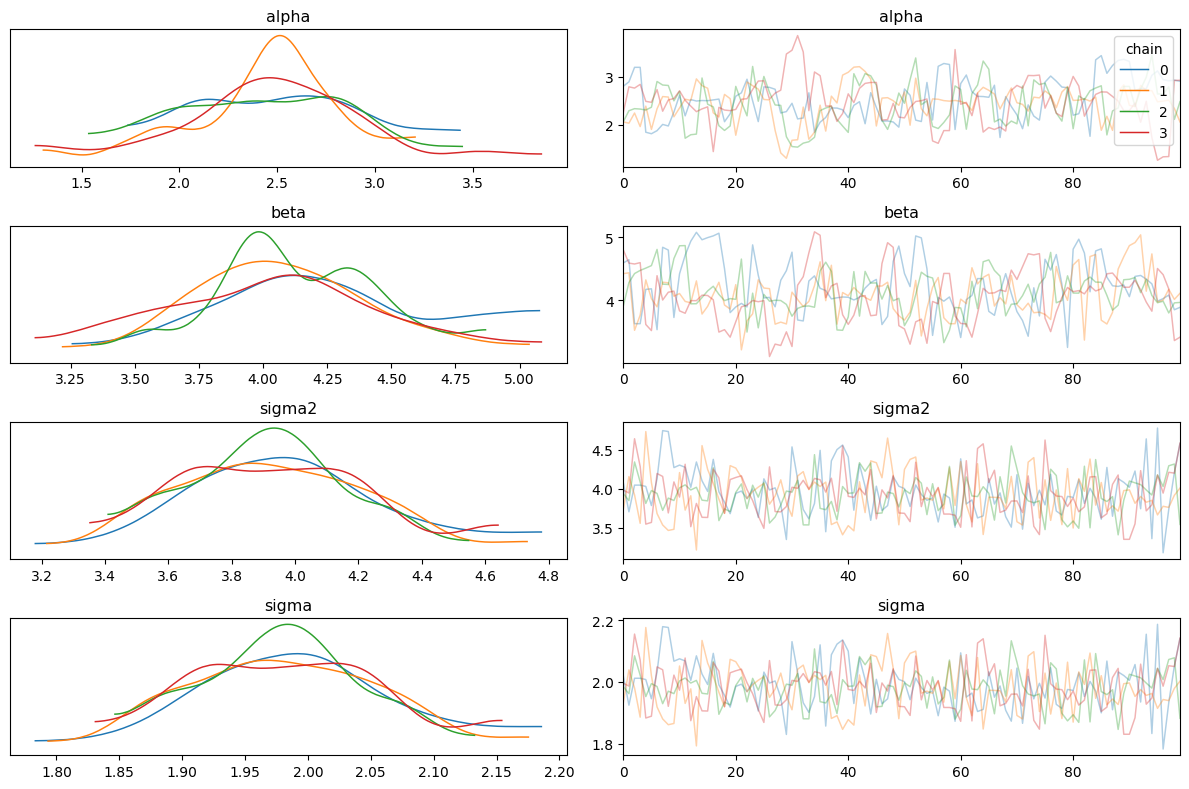

In [7]:
f = az.plot_trace(fit, compact=False, legend=True)
plt.tight_layout()

In [ ]:
#The results are chaotical and dont really fit together. 
#There is a bit of error in the beginning of the markov chain differentiation, but it mostly sticks together
#Alpha and beta had R_hat values higher than 1.01
#AND "The E-BFMI, 0.11, is below the nominal threshold of 0.30"

In [8]:

N = 1000
alpha = 2.3
sigma = 2.0
slope = 4.0
x = np.random.normal(size=N)
y = alpha + slope * x + sigma * np.random.normal(size=N)

data_dict = {
    "N": len(y),
    "y": y,
    "x": x
}

In [9]:

fit = model.sample(
    data=data_dict, 
    chains=4, 
    iter_warmup=250, 
    iter_sampling=1000,)

print(fit.diagnose())

09:55:01 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|                                                                       | 0/1250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|                                                                       | 0/1250 [00:00<?, ?it/s, (Warmup)]


chain 4:   0%|                                                                       | 0/1250 [00:00<?, ?it/s, (Warmup)]

chain 1:  16%|█████████                                                | 200/1250 [00:00<00:00, 3711.40it/s, (Sampling)]


chain 1:  68%|██████████████████████████████████████▊                  | 850/1250 [00:00<00:00, 7981.21it/s, (Sampling)]

chain 3:  76%|███████████████████████████████████████████▎             | 950/1250 [00:00<00:00, 8929.89it/s, (Sampling)]


chain 1: 100%|██████████████████████████████████████████████| 1250/1250 [00:00<00:00, 8556.72it/s, (Sampling completed)]

chain 2: 100%|██████████████████████████████████████████████| 1250/1250 [00:00<00:00, 85


09:55:01 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [10]:
az.summary(fit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,2.242,0.062,2.121,2.352,0.001,0.001,3580.0,3010.0,1.0
beta,4.096,0.065,3.971,4.218,0.001,0.001,3526.0,2812.0,1.0
sigma2,2.030,0.045,1.945,2.111,0.001,0.001,4105.0,3006.0,1.0
sigma,1.425,0.016,1.394,1.453,0.000,0.000,4105.0,3006.0,1.0


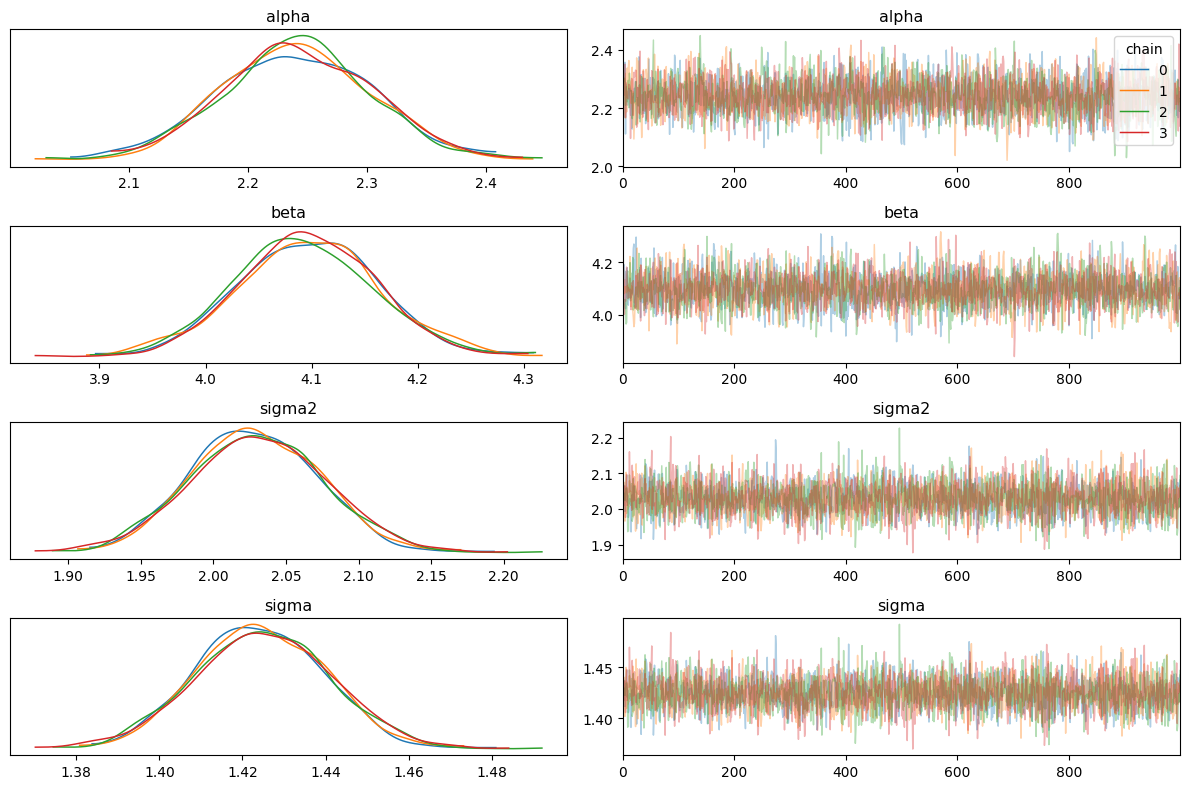

In [11]:
f = az.plot_trace(fit, compact=False, legend=True)
plt.tight_layout()

In [ ]:
#This looks far better as all of the data is put together more. 
#The chains are more or less indistinguishable unlike the previous one.
#R_hat values look far better